In [1]:
# LIBS 
import matplotlib.pyplot as plt 
import numpy as np 
# %pip install emi-receiver
from emi_receiver import receiver
import ast
from handcalcs import  render
from handcalcs import  *
import handcalcs
from localcode3 import *
fig_counter=1


import contextlib
import io
#######################################

# UTILS
def raw_to_volte(raw, dic):
    y_increment =  float(dic["y_increment"])
    y_origin =  float(dic["y_origin"])
    y_offset =  float(dic["y_offset"])
    voltage = (raw - y_offset) * y_increment + y_origin
    return voltage 
def path_to_signal(path):
    arr= np.load(path)
    yraw=arr.flatten() 
    with open(path.replace("_raw.npy","_seeting.txt")) as f:
        dic=f.read()
    # Convert string to dict
    dic = ast.literal_eval(dic)
    y=raw_to_volte(yraw, dic)
    y=y-y.mean()
    y=y/float(dic['SCALE'])
    Ts=float(dic['x_increment'])
    y = y -y.mean()
    return Ts, y


In [2]:
import scipy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# UTILS
def gaussian_stft(signal , rbw= 9e3, # 9kHz 
                  fs = 100e6,
                  step =2.5e3, # 2.5khz 
                  kind= "db"
                 ):


    # --- B. Design the "RBW" Window ---
    # We need a Gaussian window where the 6dB bandwidth equals RBW.
    sigma_f = rbw / (2 * np.sqrt(2 * np.log(2)))
    sigma_t = 1.0 / (2 * np.pi * sigma_f)
    
    # Window length (Physical Filter Width)
    win_len_sec = 6 * sigma_t 
    nperseg = int(win_len_sec * fs)
    if nperseg % 2 == 0: nperseg += 1
    
    # --- C. Configure FFT Step Size ---
    # Formula: Step = Fs / Nfft
    
    
    
    
    # Generate Gaussian Window
    sigma_samples = sigma_t * fs
    window = scipy.signal.windows.gaussian(nperseg, std=sigma_samples)
    
    # Normalize Window Energy (Sum=1 ensures correct amplitude after FFT)
    window = window / np.sum(window) 
    # --- E. Perform STFT ---
    # padded=True allows signal to be handled at boundaries


    # --- D. Overlap Configuration ---
    # 90% Overlap is standard for FFT-Scan to capture transient peaks
    overlap_ratio = 0.90 
    noverlap = int(nperseg * overlap_ratio)
    step_size = nperseg - noverlap
    # step_size = 2499
    # nperseg, len(window) =(24985, 24985)
    nfft = nperseg
    
    # Detector Timing
    fs_detector = fs / step_size
    dt_detector = 1.0 / fs_detector

    #f_axis2, t_axis2, Zxx2 
    freq, time, Z= scipy.signal.stft(
        signal, fs, 
        window=window, 
        nperseg=nperseg,    # Controls RBW Physics
        noverlap=noverlap, 
        nfft=nfft,          # Controls Frequency Step (Display)
        boundary='zeros',
        padded=True
    )
    mag = np.abs(Z)
    db = 20*np.log10(mag)
    match kind :
        case "complex":
            return freq, time, Z
        case "aa": 
            return freq, time, mag
        case "db":
            return freq, time, db



In [4]:
# Initialization 
bl= '#1520c0' # blue 
rd= '#C62828' # red
fig_counter=1

# Apres demontage et montage du setup

In [5]:
path = "EMI_2026-02-09_18-19-20-917/CH3_raw.npy"
Ts, hvp= path_to_signal(path)

path = "EMI_2026-02-12_21-58-40-610/CH3_raw.npy"
Ts, hvp_new = path_to_signal(path)

In [6]:
# AVOID printing result of calculation like 
_="""
--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------
"""
with contextlib.redirect_stdout(io.StringIO()):
    freqs, peak, avg, qp = receiver(hvp, 1/Ts, rbw=9000, band='B')

with contextlib.redirect_stdout(io.StringIO()):
    freqs2, peak2, avg2, qp2= receiver(hvp_new,1/Ts, rbw=9000, band='B')


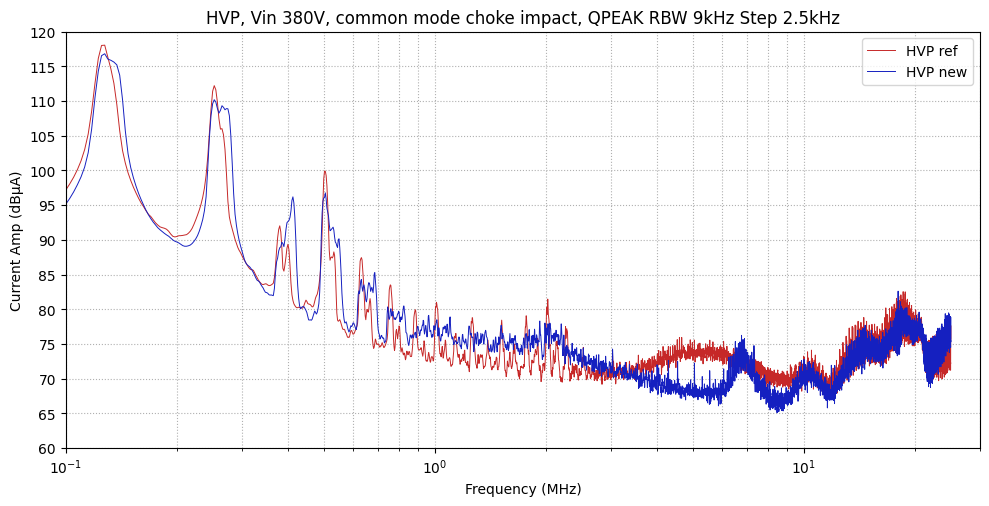

In [7]:
title="HVP, Vin 380V, common mode choke impact, QPEAK RBW 9kHz Step 2.5kHz"
plt.figure(figsize=(10,5))




plt.semilogx(freqs*1e-6, qp, label='HVP ref', color=rd, linewidth=0.7)  
plt.semilogx(freqs2*1e-6, qp2, label='HVP new', color=bl, linewidth=0.7)  

amax = 120
amin = 60

plt.ylim(amin, amax)
plt.yticks(np.arange(amin, amax+1, 5))
plt.grid(True)

plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Current Amp (dBµA)')
plt.legend()
plt.tight_layout()
plt.title(title)
plt.show()

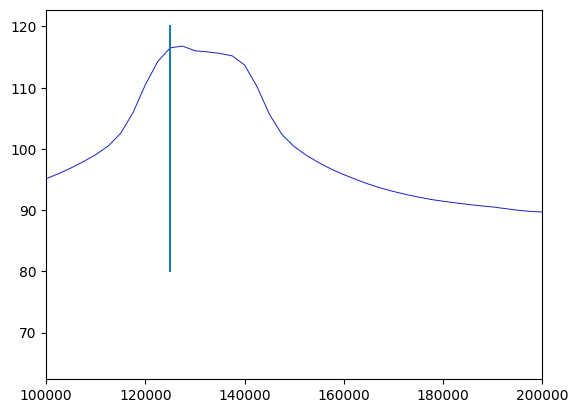

In [23]:
plt.plot(freqs2, qp2, label='HVP new', color=bl, linewidth=0.7)  
plt.xlim([100e3,200e3])
ff=125e3
plt.plot([ff,ff],[80,120])

In [8]:

freqbins, timebins, dbZ = gaussian_stft(signal = hvp, fs=1/Ts)

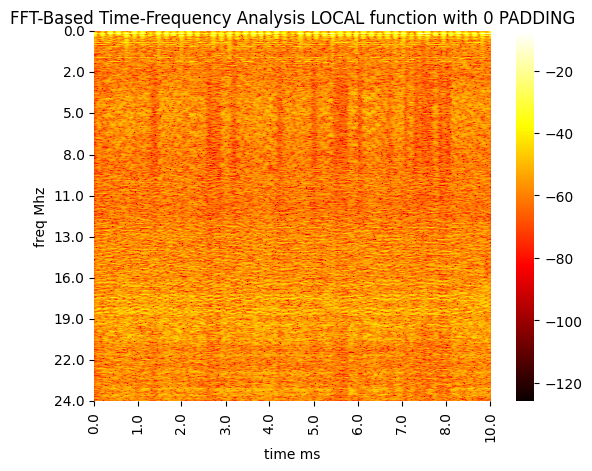

In [9]:
ax = sns.heatmap(dbZ, cmap='hot')

nx = min(10, len(timebins)); ix = np.linspace(0, len(timebins)-1, nx, dtype=int)
ny = min(10, len(freqbins)); iy = np.linspace(0, len(freqbins)-1, ny, dtype=int)

ax.set_xticks(ix); ax.set_xticklabels(np.floor(timebins[ix]*1e3))
ax.set_yticks(iy); ax.set_yticklabels(np.floor(freqbins[iy]*1e-6))


plt.title("FFT-Based Time-Frequency Analysis LOCAL function with 0 PADDING")
plt.xlabel("time ms")
plt.ylabel("freq Mhz")

plt.show()

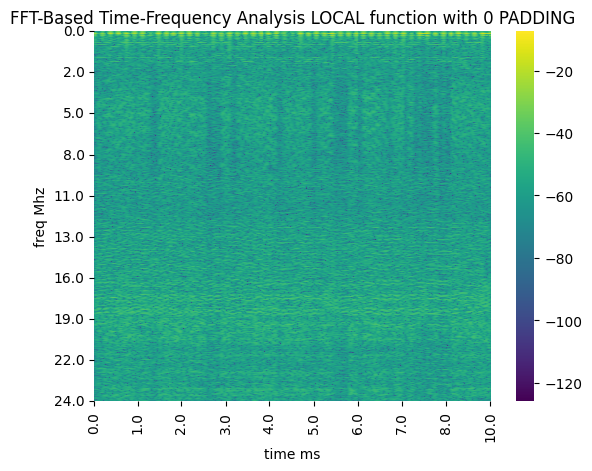

In [11]:
ax = sns.heatmap(dbZ, cmap='viridis')

nx = min(10, len(timebins)); ix = np.linspace(0, len(timebins)-1, nx, dtype=int)
ny = min(10, len(freqbins)); iy = np.linspace(0, len(freqbins)-1, ny, dtype=int)

ax.set_xticks(ix); ax.set_xticklabels(np.floor(timebins[ix]*1e3))
ax.set_yticks(iy); ax.set_yticklabels(np.floor(freqbins[iy]*1e-6))


plt.title("FFT-Based Time-Frequency Analysis LOCAL function with 0 PADDING")
plt.xlabel("time ms")
plt.ylabel("freq Mhz")

plt.show()